# Thực hiện trực quan hóa dữ liệu trên tập dữ liệu về phân loại chất lượng rượu đỏ
---
## 1. Chuẩn bị dữ liệu cho trực quan hóa dữ liệu

In [20]:
import pandas as pd

# Đọc dữ liệu
wine_data = pd.read_csv("winequality-red.csv", sep=",")

# Giữ các cột quan trọng
wine_data = wine_data[['alcohol', 'pH', 'sulphates', 'quality']]

# Tạo biến mới: tỷ lệ alcohol trên pH
wine_data['Alcohol_per_pH'] = wine_data['alcohol'] / wine_data['pH']

# Kiểm tra
print(wine_data.head())

   alcohol    pH  sulphates  quality  Alcohol_per_pH
0      9.4  3.51       0.56        5        2.678063
1      9.8  3.20       0.68        5        3.062500
2      9.8  3.26       0.65        5        3.006135
3      9.8  3.16       0.58        6        3.101266
4      9.4  3.51       0.56        5        2.678063


## 2. Trực quan hóa dữ liệu với thư viện Matplotlib

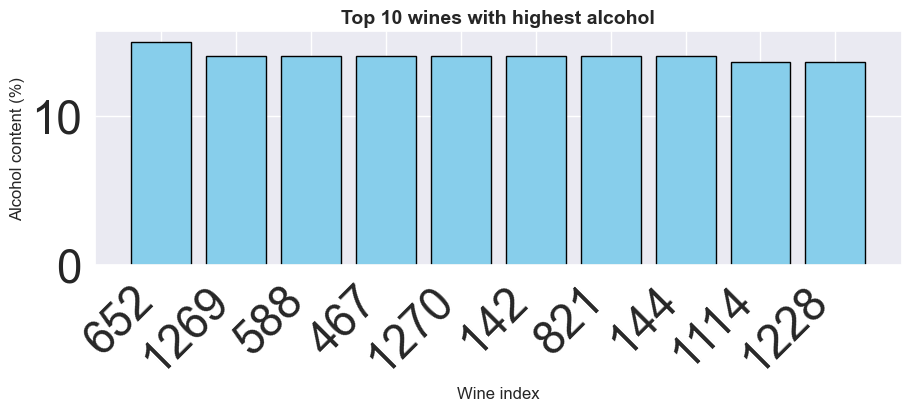

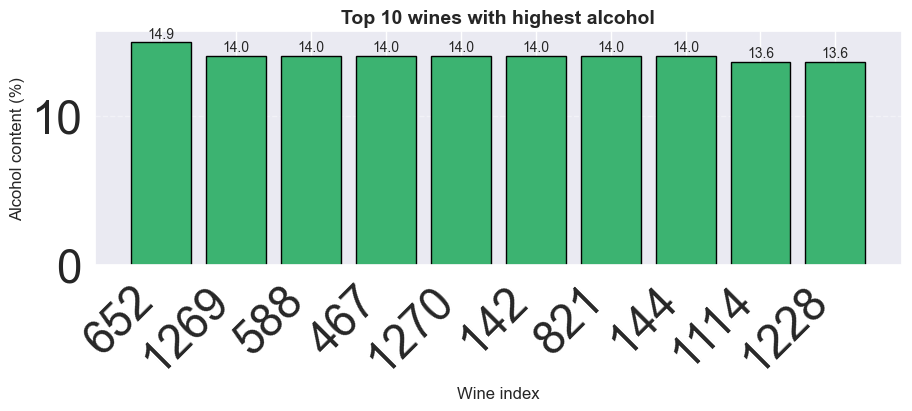

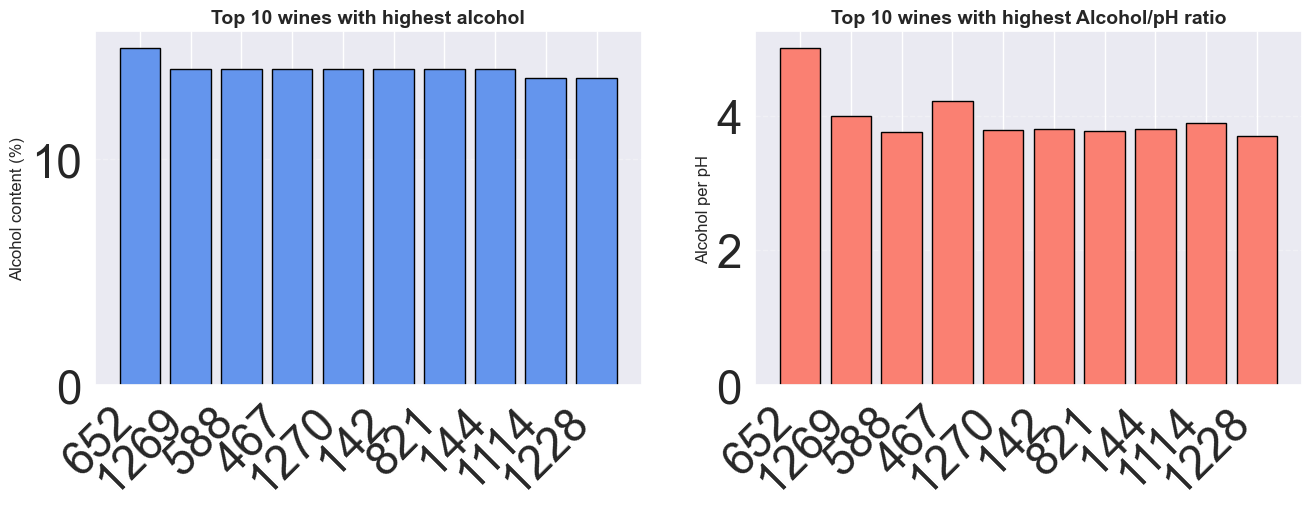

In [26]:
import matplotlib.pyplot as plt
import numpy as np

# Sắp xếp dữ liệu theo độ cồn giảm dần
wine_sorted = wine_data.sort_values('alcohol', ascending=False).head(10)

# Tạo chỉ số và nhãn (index thật)
x = np.arange(len(wine_sorted))
labels = wine_sorted.index.astype(str)

#  Case 1
plt.figure(figsize=(10,5))
plt.bar(x, wine_sorted['alcohol'], color='skyblue', edgecolor='black')
plt.xticks(x, labels, rotation=45, ha='right')
plt.xlabel('Wine index', fontsize=12)
plt.ylabel('Alcohol content (%)', fontsize=12)
plt.title('Top 10 wines with highest alcohol', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


# Case 2
plt.figure(figsize=(10,5))
bars = plt.bar(x, wine_sorted['alcohol'], color='mediumseagreen', edgecolor='black')

# Hiển thị giá trị trên đầu cột
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.1,
             f'{height:.1f}', ha='center', va='bottom', fontsize=10)

plt.xticks(x, labels, rotation=45, ha='right')
plt.xlabel('Wine index', fontsize=12)
plt.ylabel('Alcohol content (%)', fontsize=12)
plt.title('Top 10 wines with highest alcohol', fontsize=14, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


# Case 3
fig, axes = plt.subplots(1, 2, figsize=(14,6))

# Biểu đồ 1: Alcohol
axes[0].bar(x, wine_sorted['alcohol'], color='cornflowerblue', edgecolor='black')
axes[0].set_title('Top 10 wines with highest alcohol', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Alcohol content (%)', fontsize=12)
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, rotation=45, ha='right')
axes[0].grid(axis='y', linestyle='--', alpha=0.3)

# Biểu đồ 2: Alcohol/pH
axes[1].bar(x, wine_sorted['Alcohol_per_pH'], color='salmon', edgecolor='black')
axes[1].set_title('Top 10 wines with highest Alcohol/pH ratio', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Alcohol per pH', fontsize=12)
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, rotation=45, ha='right')
axes[1].grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()


## 3. Trực quan hóa dữ liệu với thư viện Seaborn

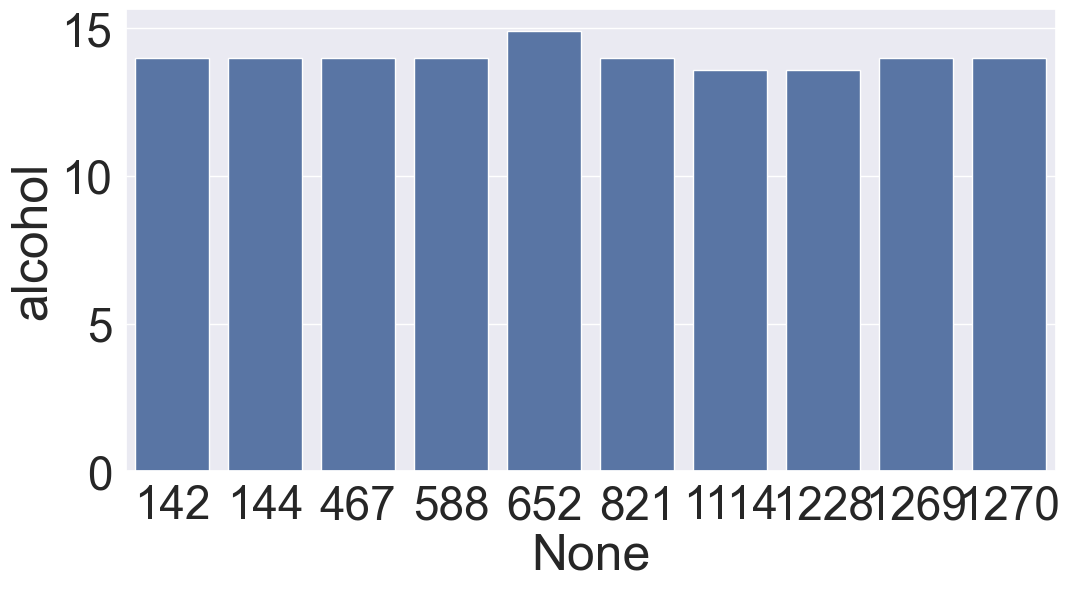

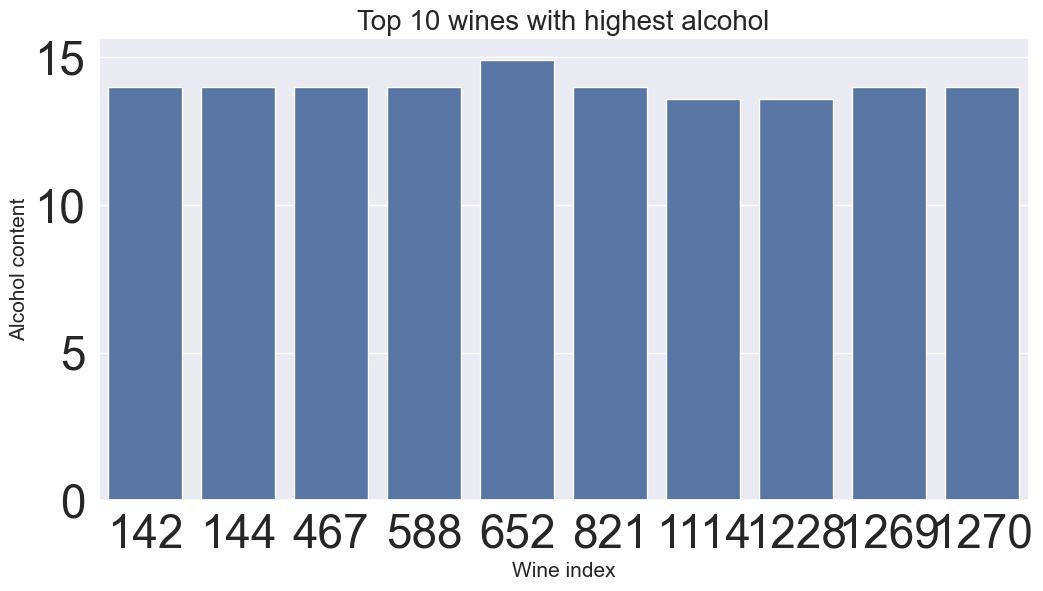

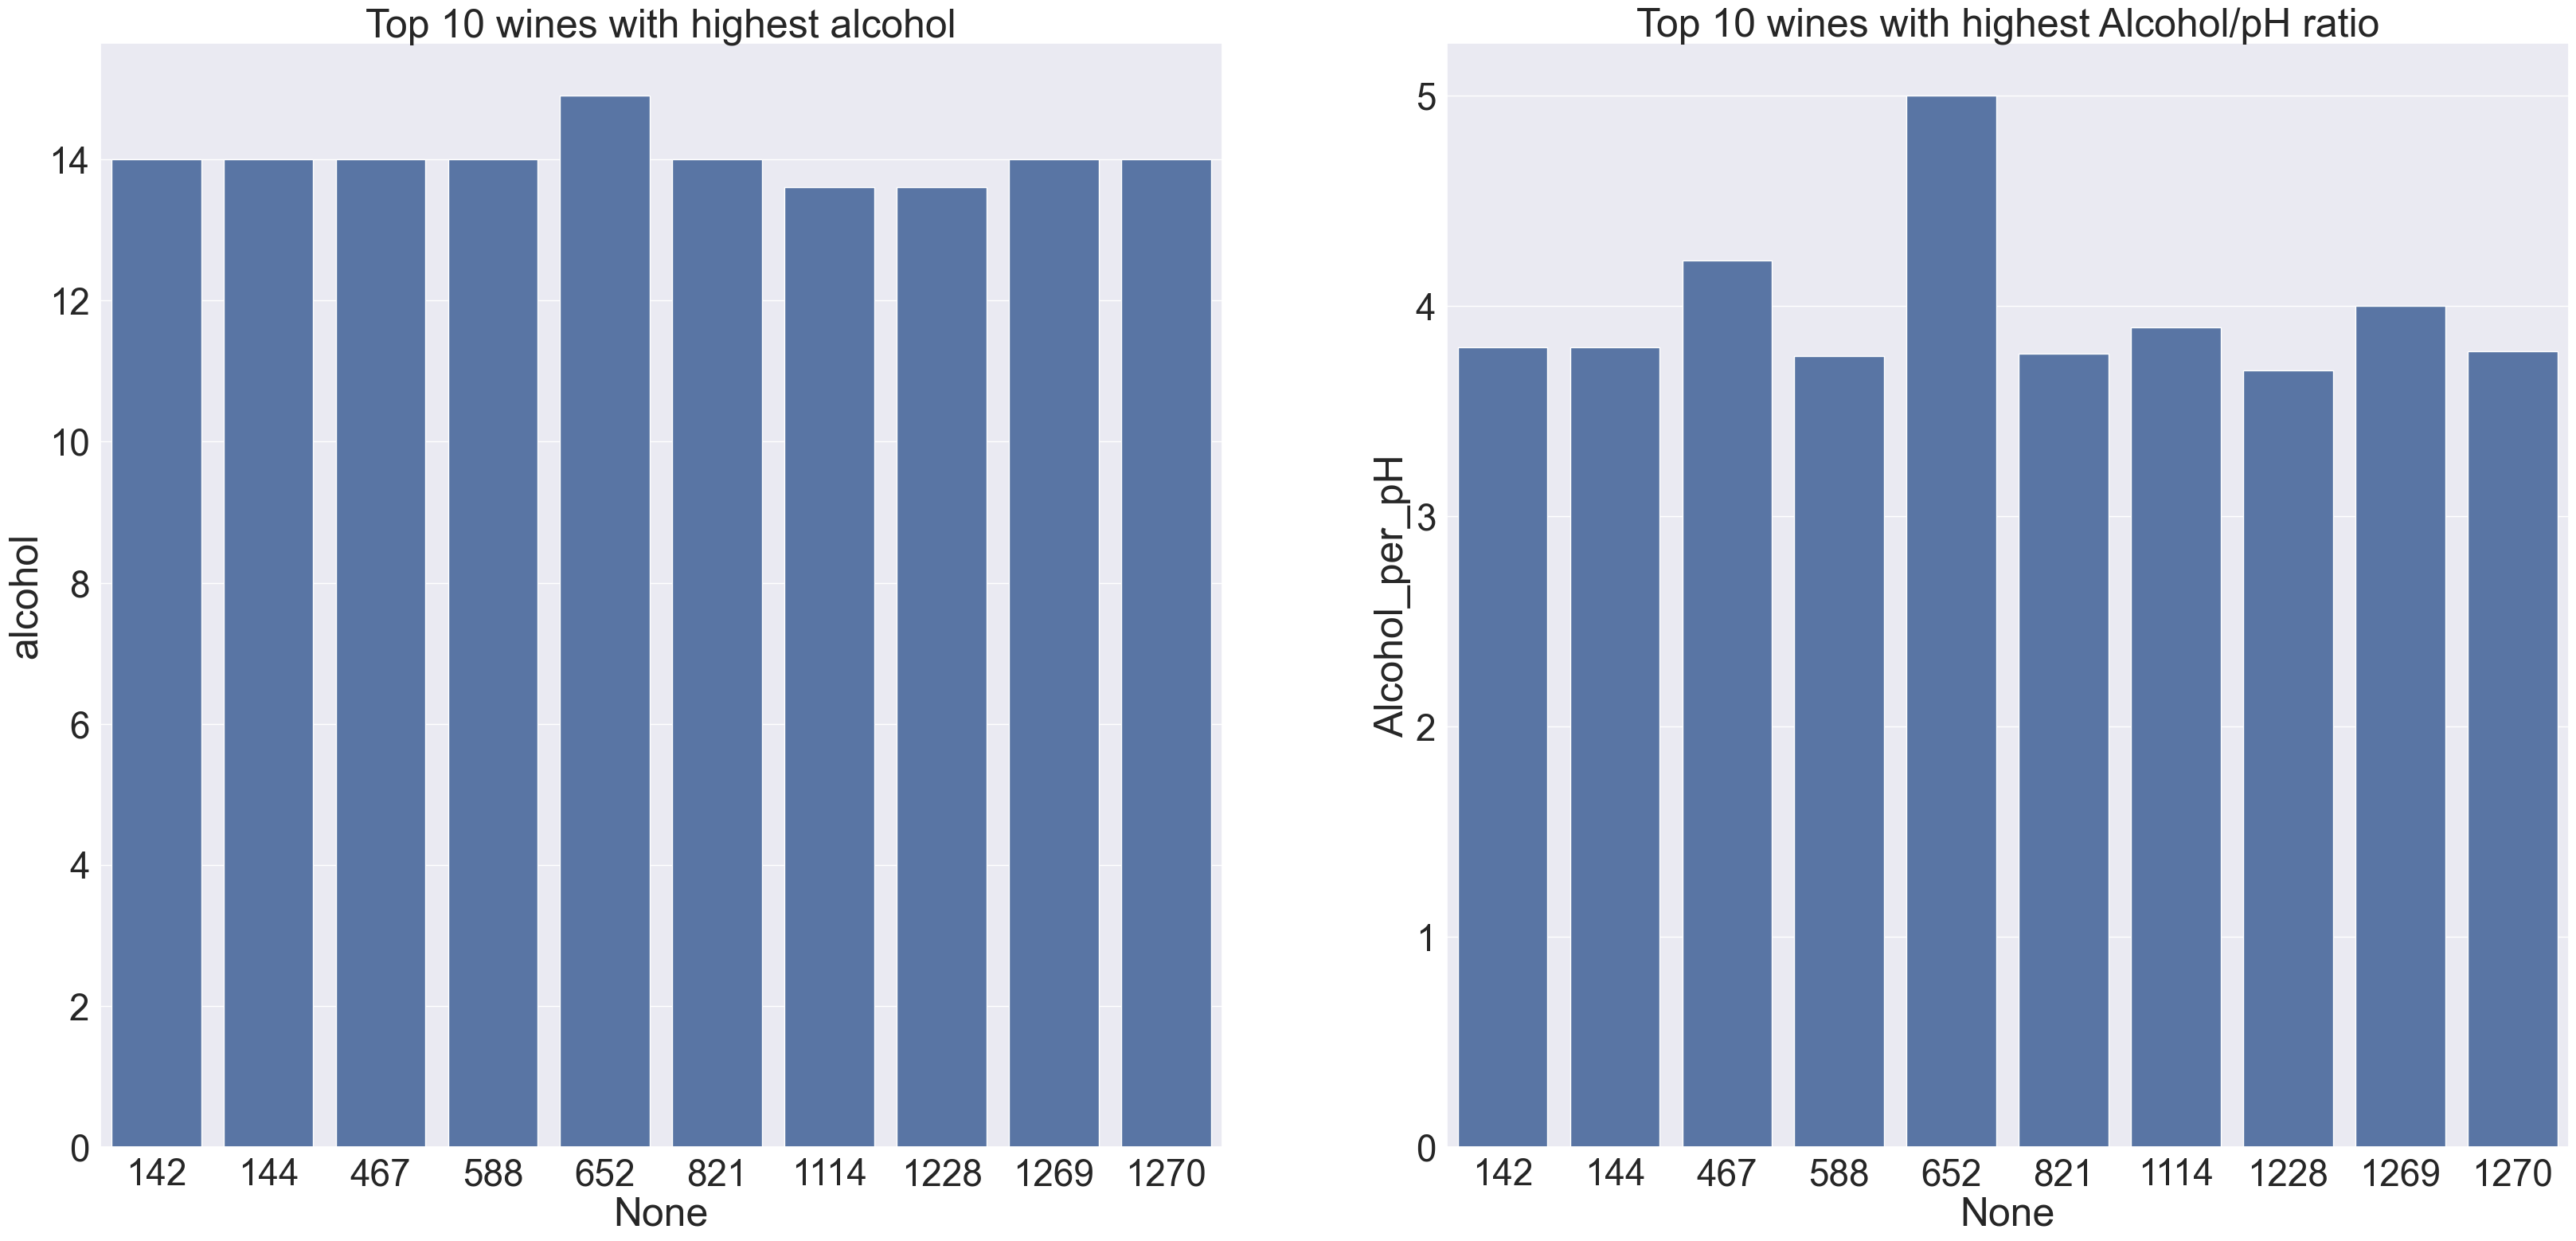

In [23]:
import seaborn as sns
# Case 1: Basic
plt.figure(figsize=(12,6))
data = wine_sorted.head(10)
sns.barplot(data=data, x=data.index, y='alcohol')
plt.show()

# Case 2: Advanced
plt.figure(figsize=(12,6))
data = wine_sorted.head(10)
ax = sns.barplot(data=data, x=data.index, y='alcohol')
ax.set_xlabel('Wine index', fontsize=15)
ax.set_ylabel('Alcohol content', fontsize=15)
ax.set_title('Top 10 wines with highest alcohol', fontsize=20)
plt.show()

# Case 3: Nhiều góc nhìn
fig, ax = plt.subplots(1, 2, figsize=(40,18))
data = wine_sorted.head(10)
sns.set(font_scale=3)

# Biểu đồ 1
ax1 = sns.barplot(data=data, x=data.index, y='alcohol', ax=ax[0])
ax1.set_title('Top 10 wines with highest alcohol')

# Biểu đồ 2
ax2 = sns.barplot(data=data, x=data.index, y='Alcohol_per_pH', ax=ax[1])
ax2.set_title('Top 10 wines with highest Alcohol/pH ratio')

plt.show()

# Kết thúc